# 04 · M4 Transformer encoder (multi-head self-attention)

**Owner:** Riddhi Puneyani  
Scripts: `src/models/m4_transformer.py`, shared trainer `src/models/deep_common.py`. Fixed configuration (no metaheuristic search), RMSprop, 3 seeds.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
from m4_transformer import build, CONFIG
CFG, TAG = CONFIG, "m4_transformer"
print(CFG)
build(CFG).summary()

{'lr': 0.0005, 'd_model': 32, 'heads': 4, 'ff': 64, 'layers': 2, 'patch': 4, 'dropout': 0.1, 'dense': 64}


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ beat (InputLayer)   │ (None, 360, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 90, 32)    │        320 │ beat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 90, 32)    │      2,880 │ conv1d[0][0]      │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 90, 32)    │         64 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 90, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 90, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 90, 32)    │          0 │ positional_embed… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 90, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 90, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 90, 32)    │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 90, 32)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 90, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 90, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 90, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 90, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 90, 32)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 90, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 90, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 90, 32)    │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 90, 32)    │          0 │ dense_3[0][0]   

 Total params: 23,045 (90.02 KB)

 Trainable params: 23,045 (90.02 KB)

 Non-trainable params: 0 (0.00 B)

## Shared training procedure (deep_common.py)
RMSprop, inverse-sqrt class weights, early stopping on validation macro-F1 (N/S/V/F), deterministic seeds.

In [3]:
from deep_common import class_weights, load_data, MAX_EPOCHS, PATIENCE, BATCH_SIZE
from config import CLASSES
d = load_data()
print("class weights:", {CLASSES[k]: round(v, 2) for k, v in class_weights(d["train"][2]).items()})
print("max epochs", MAX_EPOCHS, "patience", PATIENCE, "batch", BATCH_SIZE)

class weights: {'N': 0.47, 'S': 3.29, 'V': 1.64, 'F': 4.47, 'Q': 20.0}
max epochs 30 patience 5 batch 128


In [4]:
# Re-score the saved weights of every seed on DS2 and check they reproduce the
# numbers stored in results/ by the training script.
from deep_common import load_data, load_trained, predict
from evaluate import score
from config import SEEDS, CLASSES
data = load_data()
Xte, Fte, yte = data['test']
rows = []
for seed in SEEDS:
    model = load_trained(build, CFG, TAG, seed)
    m = score(yte, predict(model, Xte, Fte))
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        saved = json.load(fh)
    rows.append((seed, m['accuracy'], m['macro_f1'], m['macro_f1_nsvf'],
                 abs(m['macro_f1'] - saved['macro_f1']) < 1e-9))
print('seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved')
for r in rows:
    print(f'{r[0]:4d}  {r[1]:.4f}    {r[2]:.4f}    {r[3]:.4f}          {r[4]}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:04:39.454464: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:04:52.261736: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:05:04.844023: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved
  42  0.8617    0.3546    0.4390          True
  43  0.9360    0.4358    0.5448          True
  44  0.9130    0.3866    0.4833          True


DS2 macro-F1 0.3924 +/- 0.0334 (N/S/V/F: 0.4890 +/- 0.0434)
class   recall           F1
  N    0.944 ± 0.036    0.948 ± 0.018   (n=44228)
  S    0.197 ± 0.059    0.254 ± 0.107   (n=1836)
  V    0.857 ± 0.061    0.753 ± 0.054   (n=3220)
  F    0.001 ± 0.001    0.001 ± 0.001   (n=388)
  Q    0.048 ± 0.067    0.006 ± 0.008   (n=7)


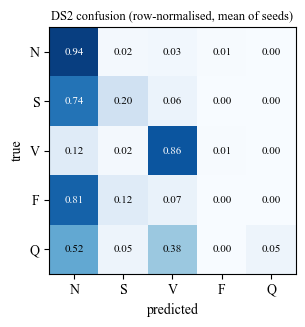

In [5]:
with open(os.path.join(ROOT, 'results', f'{TAG}.json')) as fh:
    agg = json.load(fh)
print(f"DS2 macro-F1 {agg['macro_f1']['mean']:.4f} +/- {agg['macro_f1']['std']:.4f} "
      f"(N/S/V/F: {agg['macro_f1_nsvf']['mean']:.4f} +/- {agg['macro_f1_nsvf']['std']:.4f})")
print('class   recall           F1')
for c in CLASSES:
    r, f = agg['per_class_recall'][c], agg['per_class_f1'][c]
    print(f"  {c}    {r['mean']:.3f} ± {r['std']:.3f}    {f['mean']:.3f} ± {f['std']:.3f}   (n={agg['support'][c]})")
cm = np.array(agg['confusion_matrix_sum']) / len(agg['seeds'])
norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{norm[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if norm[i,j] > .55 else 'black')
ax.set_xticks(range(5), CLASSES); ax.set_yticks(range(5), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('DS2 confusion (row-normalised, mean of seeds)', fontsize=9)
plt.show()

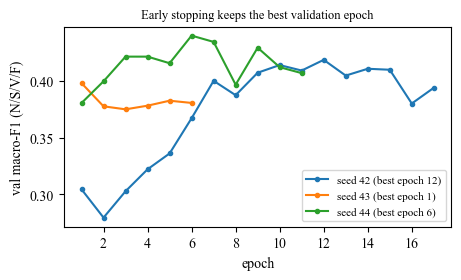

In [6]:
fig, ax = plt.subplots(figsize=(5, 2.6))
for seed in SEEDS:
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        r = json.load(fh)
    h = r['history']
    ax.plot([e['epoch'] for e in h], [e['val_macro_f1_nsvf'] for e in h], marker='o', ms=3,
            label=f"seed {seed} (best epoch {r['best_epoch']})")
ax.set_xlabel('epoch'); ax.set_ylabel('val macro-F1 (N/S/V/F)'); ax.legend(fontsize=8)
ax.set_title('Early stopping keeps the best validation epoch', fontsize=9)
plt.show()

In [7]:
# Full retraining (3 seeds). Takes 30-60 min on a laptop CPU, a few minutes
# on a Colab GPU. Uncomment to reproduce results/m4_transformer.json from scratch.
# !cd .. && python src/models/m4_transformer.py

# Final phase: grouped cross-validation and final model

The Transformer kept the multi-beat context input (3 s at 120 Hz) and training-time augmentation.

All choices below were made on DS1 only, with 4-fold grouped cross-validation over its 22 patients (`src/cv.py`). The final model was trained on all 22 DS1 patients on a Colab GPU and DS2 was scored once.

In [8]:
TAG, INTERIM_TAG = 'm4_transformer', 'm4_transformer'
sel = json.load(open(os.path.join(ROOT, 'results', 'final', TAG, 'selected.json')))
print('selected variant:', sel['variant'], '| epochs:', sel['epochs'])
print('config:', sel['config'])
print('calibration offsets (N,S,V,F,Q):', [round(v, 2) for v in sel['offsets']])
print('\nablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):')
for l in sel['ablation_log']:
    print(f"  {l['step']:10s} {l['cv_macro_f1_nsvf']:.4f}  {'kept' if l['kept'] else 'rejected'}")

selected variant: baseline+context+augment | epochs: 12
config: {'lr': 0.0005, 'd_model': 32, 'heads': 4, 'ff': 64, 'layers': 2, 'patch': 4, 'dropout': 0.1, 'dense': 64, 'input': 'context', 'augment': True}
calibration offsets (N,S,V,F,Q): [0.0, -0.75, -1.75, 0.0, 0.0]

ablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):
  baseline   0.4488  kept
  context    0.4657  kept
  augment    0.5174  kept
  focal      0.4846  rejected


### Final weights re-scored on CPU (reproducibility check)

In [9]:
# Rebuild each final model, load its weights and score DS2 on CPU; compare with the stored results.
import numpy as np
from deep_common import load_arrays, predict_proba, scaled_rr
from calibrate import apply as apply_offsets
from evaluate import score
cfg, offsets = sel['config'], np.array(sel['offsets'])
d = load_arrays(cfg.get('input', 'beat'))
tr, te = np.flatnonzero(d['split'] != 'test'), np.flatnonzero(d['split'] == 'test')
_, Fte = scaled_rr(d['F'], tr, te)
print('seed  raw macro-F1  calibrated  matches stored')
for seed in (42, 43, 44):
    m = build(cfg)
    m.load_weights(os.path.join(ROOT, 'saved_models', 'final', f'{TAG}_seed{seed}.weights.h5'))
    p = predict_proba(m, d['X'][te], Fte)
    raw, cal = score(d['y'][te], p.argmax(1)), score(d['y'][te], apply_offsets(p, offsets))
    stored = json.load(open(os.path.join(ROOT, 'results', 'final', 'runs', f'{TAG}_seed{seed}.json')))
    ok = abs(raw['macro_f1'] - stored['raw']['macro_f1']) < 1e-9 and abs(cal['macro_f1'] - stored['calibrated']['macro_f1']) < 1e-9
    print(f"{seed:4d}  {raw['macro_f1']:.4f}        {cal['macro_f1']:.4f}      {ok}")

seed  raw macro-F1  calibrated  matches stored


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:05:17.850876: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  42  0.3414        0.3550      True


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:05:30.577533: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  43  0.3858        0.3943      True


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 43 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:05:43.337300: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  44  0.3947        0.3996      True


### Interim vs final on DS2 (mean ± std over 3 seeds)

In [10]:
fin = json.load(open(os.path.join(ROOT, 'results', 'final', f'{TAG}.json')))
old = json.load(open(os.path.join(ROOT, 'results', f'{INTERIM_TAG}.json')))
print(f"interim          macro-F1 {old['macro_f1']['mean']:.3f} ± {old['macro_f1']['std']:.3f}")
for kind in ['raw', 'calibrated']:
    r = fin[kind]
    print(f"final {kind:10s} macro-F1 {r['macro_f1']['mean']:.3f} ± {r['macro_f1']['std']:.3f}  | recall "
          + '  '.join(f"{c} {r['per_class_recall'][c]['mean']:.2f}" for c in 'NSVF'))

interim          macro-F1 0.392 ± 0.033
final raw        macro-F1 0.374 ± 0.023  | recall N 0.92  S 0.13  V 0.87  F 0.11
final calibrated macro-F1 0.383 ± 0.020  | recall N 0.94  S 0.12  V 0.81  F 0.14
